In [6]:
#ML moodel implmentation steps
#1.Problem Analysis
#2.Data Collection
#3.Cleaning and preprocessing the data---pandas, numpy
#4.Visualization of data---matplotlib,seaborn
#5.Lebeling of data---(x,input data, features, independent values)(y,ouput data, target, dependent values)
#6.Split the data fro training and testing---(training--80%)(testing--20%)
#7. model Building --Algorithm selection
#8.Train the model---(using X_train and y_train)
#9Testing the model---(x_test--->predicted value)
#10. model evolution --(predicted value ---y_test)
#11.model deployemnt

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("C:\\Users\\HP\\Downloads\\Food_Delivery_Times.csv")
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [8]:
#Data understanding/data inspections

In [9]:
#head()--top 5 rows 
print(df.head(10))

   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   
5       679        19.40   Clear           Low     Evening      Scooter   
6       627         9.52   Clear           Low         NaN         Bike   
7       514        17.39   Clear        Medium     Evening      Scooter   
8       860         1.78   Snowy           Low     Evening          Car   
9       137        10.62   Foggy           Low     Evening      Scooter   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20             

In [10]:
#tail()---bottom 5 rows
print(df.tail(8))

     Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
992        21        12.43   Rainy          High     Morning         Bike   
993       701        10.89   Windy        Medium     Evening         Bike   
994        72         4.37   Clear        Medium     Evening      Scooter   
995       107         8.50   Clear          High     Evening          Car   
996       271        16.28   Rainy           Low     Morning      Scooter   
997       861        15.62   Snowy          High     Evening      Scooter   
998       436        14.17   Clear           Low   Afternoon         Bike   
999       103         6.63   Foggy           Low       Night      Scooter   

     Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
992                    13                     6.0                 70  
993                     7                     0.0                 58  
994                     6                     7.0                 25  
995                   

In [11]:
#sample()---to get random rows--default--1 row
print(df.sample(3))

     Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
371       706        19.80   Clear          High     Evening         Bike   
234        34        19.00   Clear          High     Morning          Car   
871       129         0.64   Clear          High       Night         Bike   

     Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
371                     7                     3.0                 88  
234                    28                     3.0                 96  
871                    10                     3.0                 24  


In [12]:
#to check data types
print(df.dtypes)

Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object


In [13]:
#info()---overall information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB
None


In [14]:
#describe
print(df.describe())

          Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
count  1000.000000  1000.000000           1000.000000              970.000000   
mean    500.500000    10.059970             16.982000                4.579381   
std     288.819436     5.696656              7.204553                2.914394   
min       1.000000     0.590000              5.000000                0.000000   
25%     250.750000     5.105000             11.000000                2.000000   
50%     500.500000    10.190000             17.000000                5.000000   
75%     750.250000    15.017500             23.000000                7.000000   
max    1000.000000    19.990000             29.000000                9.000000   

       Delivery_Time_min  
count        1000.000000  
mean           56.732000  
std            22.070915  
min             8.000000  
25%            41.000000  
50%            55.500000  
75%            71.000000  
max           153.000000  


In [15]:
#shape --rows and column 
print(df.shape)

(1000, 9)


In [16]:
print(df.columns)

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')


In [17]:
#textual column information
col=['Weather','Traffic_Level', 'Time_of_Day',
       'Vehicle_Type',]
for i in col:
    print("column name:",i)
    print(df[i].unique())
    print(df[i].value_counts())
    print("=====================================")

column name: Weather
['Windy' 'Clear' 'Foggy' 'Rainy' 'Snowy' nan]
Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64
column name: Traffic_Level
['Low' 'Medium' 'High' nan]
Traffic_Level
Medium    390
Low       383
High      197
Name: count, dtype: int64
column name: Time_of_Day
['Afternoon' 'Evening' 'Night' 'Morning' nan]
Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64
column name: Vehicle_Type
['Scooter' 'Bike' 'Car']
Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64


In [18]:
#check null values
print(df.isnull().sum())

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [19]:
#textual column---forward fill,backward fill, mode
#numeric columns --mean ,median,mode

In [20]:
#filling null values
df['Weather'].ffill(inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_9472\1037753256.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weather'].ffill(inplace=True)


In [21]:
#check null values
print(df.isnull().sum())

Order_ID                   0
Distance_km                0
Weather                    0
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [22]:
df['Traffic_Level'].ffill(inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_9472\809921629.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Traffic_Level'].ffill(inplace=True)


In [23]:
df['Time_of_Day'].ffill(inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_9472\2155971072.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Time_of_Day'].ffill(inplace=True)


In [24]:
mean=df['Courier_Experience_yrs'].mean()
print(mean)

4.579381443298969


In [25]:
mean=df['Courier_Experience_yrs'].fillna(4.5,inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_9472\4281174585.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mean=df['Courier_Experience_yrs'].fillna(4.5,inplace=True)


In [26]:
print(df.isnull().sum())

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


In [27]:
#check Duplicates
print(df[df.duplicated()])

Empty DataFrame
Columns: [Order_ID, Distance_km, Weather, Traffic_Level, Time_of_Day, Vehicle_Type, Preparation_Time_min, Courier_Experience_yrs, Delivery_Time_min]
Index: []


In [28]:
#Drop unnecessary column
df.drop('Order_ID', axis=1, inplace=True, errors='ignore') #default axis=0--row deletion

df.columns

In [29]:
df.columns

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [30]:
#visualization 
#Distribution of weather types
a=df['Weather'].value_counts()
print(a)
x=a.index
print(x)
y=a.values
print(y)

Weather
Clear    481
Rainy    215
Foggy    105
Snowy    100
Windy     99
Name: count, dtype: int64
Index(['Clear', 'Rainy', 'Foggy', 'Snowy', 'Windy'], dtype='object', name='Weather')
[481 215 105 100  99]


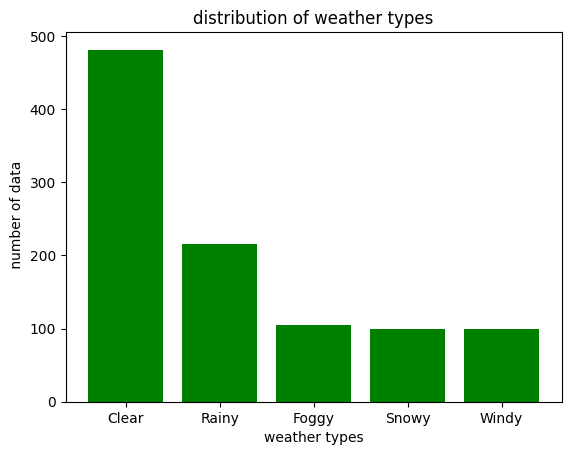

In [31]:
plt.bar(x,y,color='g')
plt.title("distribution of weather types")
plt.xlabel("weather types")
plt.ylabel(" number of data")
plt.show()

In [32]:
#Task
#create followig visualization
#1 Distribution of traffic level---horizontal bar chart 
#2 distribution of vehicle typw ---pie chart
#3 distribution of time of day-- bar chart
#4 distance v/s delivery time-- line graph
#5 distribution of preparation time ---histogram

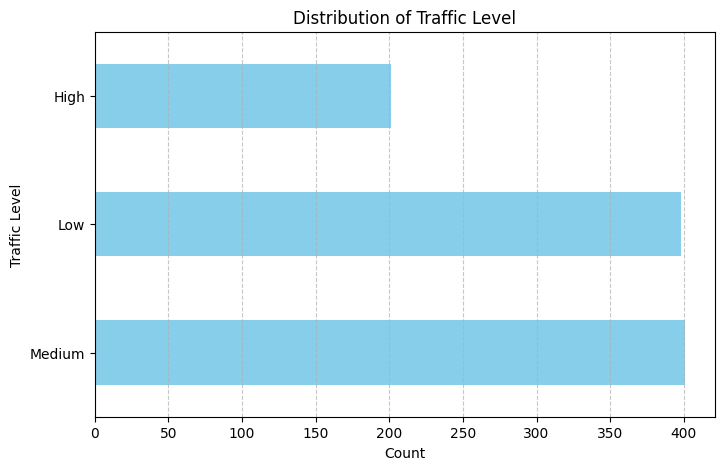

In [33]:

# 1. Distribution of Traffic Level (Horizontal Bar Chart)

traffic_counts = df['Traffic_Level'].value_counts()

plt.figure(figsize=(8,5))
traffic_counts.plot(kind='barh', color='skyblue')
plt.title("Distribution of Traffic Level")
plt.xlabel("Count")
plt.ylabel("Traffic Level")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

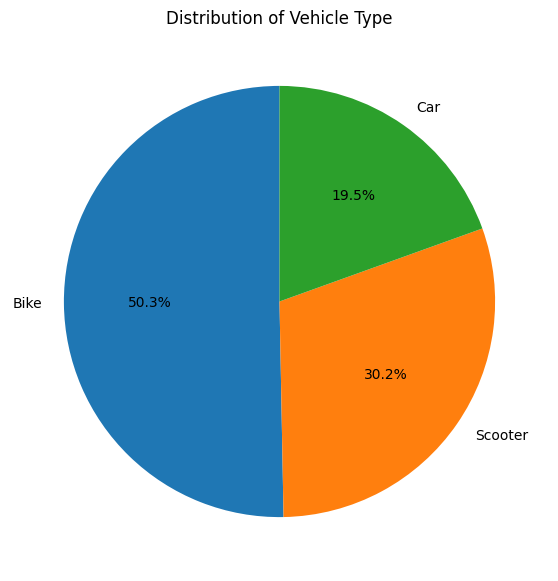

In [34]:
# 2. Distribution of Vehicle Type (Pie Chart)

vehicle_counts = df['Vehicle_Type'].value_counts()

plt.figure(figsize=(7,7))
vehicle_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Distribution of Vehicle Type")
plt.ylabel("")
plt.show()


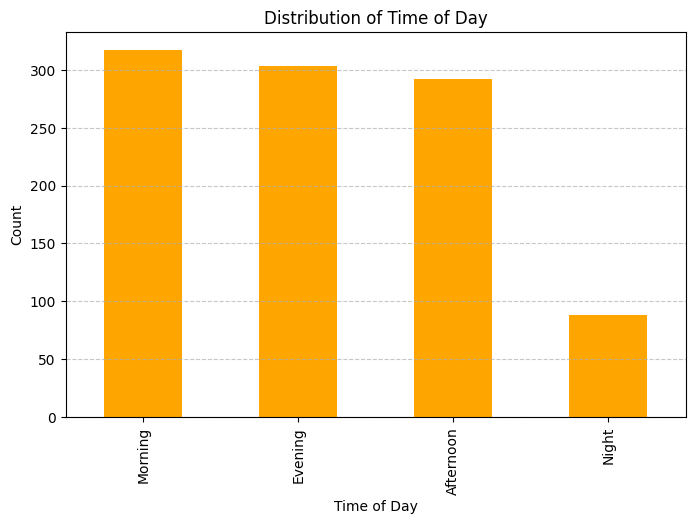

In [35]:

# 3. Distribution of Time of Day (Bar Chart)

time_counts = df['Time_of_Day'].value_counts()

plt.figure(figsize=(8,5))
time_counts.plot(kind='bar', color='orange')
plt.title("Distribution of Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


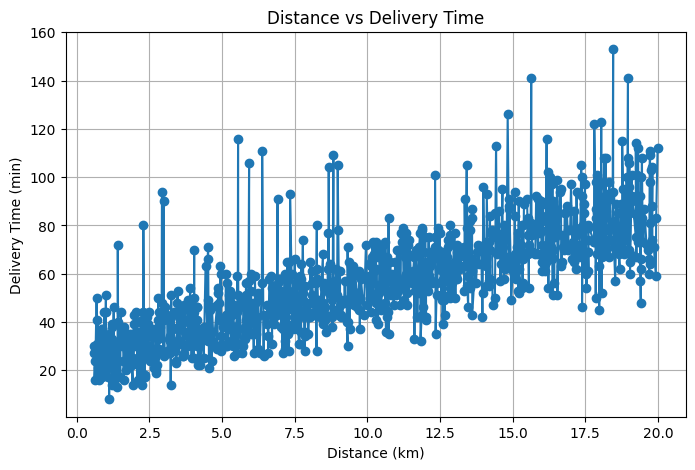

In [36]:

# 4. Distance vs Delivery Time (Line Graph)

df_sorted = df.sort_values(by='Distance_km')

plt.figure(figsize=(8,5))
plt.plot(df_sorted['Distance_km'],
         df_sorted['Delivery_Time_min'],
         marker='o')
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.grid(True)
plt.show()

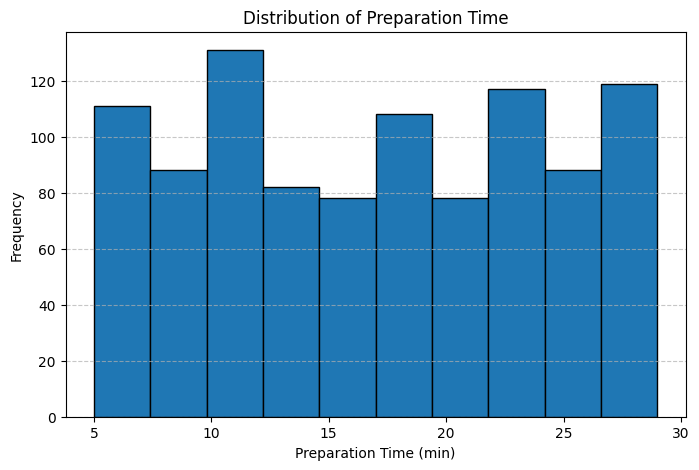

In [37]:

# 5. Distribution of Preparation Time (Histogram)

plt.figure(figsize=(8,5))
plt.hist(df['Preparation_Time_min'],
         bins=10,
         edgecolor='black')
plt.title("Distribution of Preparation Time")
plt.xlabel("Preparation Time (min)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [38]:
#Encoding
#Encoding:Textual data to numeric
#Nominal data(you cannot order or sort the data ex:Male and female) and ordinal data(you can order or sort like age)
# 1 Dummy encodig--pandas
# 2 one hot encoding--sklearn

#ordinal data(you can order or sort like age,salary)
# 1 label encoding--sklearn
# 2 map() function

In [39]:
df

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [40]:
#Dummy encoding --weather column
0

,Distance_km,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy
0,7.93,Low,Afternoon,Scooter,12,1.0,43,0,0,0,0,1
1,16.42,Medium,Evening,Bike,20,2.0,84,1,0,0,0,0
2,9.52,Low,Night,Scooter,28,1.0,59,0,1,0,0,0
3,7.44,Medium,Afternoon,Scooter,5,1.0,37,0,0,1,0,0
4,19.03,Low,Morning,Bike,16,5.0,68,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.50,High,Evening,Car,13,3.0,54,1,0,0,0,0
996,16.28,Low,Morning,Scooter,8,9.0,71,0,0,1,0,0
997,15.62,High,Evening,Scooter,26,2.0,81,0,0,0,1,0
998,14.17,Low,Afternoon,Bike,8,0.0,55,1,0,0,0,0


In [41]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
#one hot encoding --time_of_day
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(drop=None,sparse_output=False) #sparse _output
encoded=encoder.fit_transform(df[['Time_of_Day']])# aplly encoding to our column
 ## create dataFrame with new columns
encoded_df=pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Time_of_Day']))
print(encoded_df)

                                  

     Time_of_Day_Afternoon  Time_of_Day_Evening  Time_of_Day_Morning  \
0                      1.0                  0.0                  0.0   
1                      0.0                  1.0                  0.0   
2                      0.0                  0.0                  0.0   
3                      1.0                  0.0                  0.0   
4                      0.0                  0.0                  1.0   
..                     ...                  ...                  ...   
995                    0.0                  1.0                  0.0   
996                    0.0                  0.0                  1.0   
997                    0.0                  1.0                  0.0   
998                    1.0                  0.0                  0.0   
999                    0.0                  0.0                  0.0   

     Time_of_Day_Night  
0                  0.0  
1                  0.0  
2                  1.0  
3                  0.0  
4         

In [43]:
#concatenate with original DataFrame (dropping old column)
df=pd.concat([df.drop('Time_of_Day',axis=1),encoded_df],axis=1)
df.head()

,Distance_km,Traffic_Level,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night
0,7.93,Low,Scooter,12,1.0,43,0,0,0,0,1,1.0,0.0,0.0,0.0
1,16.42,Medium,Bike,20,2.0,84,1,0,0,0,0,0.0,1.0,0.0,0.0
2,9.52,Low,Scooter,28,1.0,59,0,1,0,0,0,0.0,0.0,0.0,1.0
3,7.44,Medium,Scooter,5,1.0,37,0,0,1,0,0,1.0,0.0,0.0,0.0
4,19.03,Low,Bike,16,5.0,68,1,0,0,0,0,0.0,0.0,1.0,0.0


In [44]:
#dummy encoding --vehicle_type column
df=pd.get_dummies(df,columns=['Vehicle_Type'],dtype='int')
df

,Distance_km,Traffic_Level,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,Low,12,1.0,43,0,0,0,0,1,1.0,0.0,0.0,0.0,0,0,1
1,16.42,Medium,20,2.0,84,1,0,0,0,0,0.0,1.0,0.0,0.0,1,0,0
2,9.52,Low,28,1.0,59,0,1,0,0,0,0.0,0.0,0.0,1.0,0,0,1
3,7.44,Medium,5,1.0,37,0,0,1,0,0,1.0,0.0,0.0,0.0,0,0,1
4,19.03,Low,16,5.0,68,1,0,0,0,0,0.0,0.0,1.0,0.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.50,High,13,3.0,54,1,0,0,0,0,0.0,1.0,0.0,0.0,0,1,0
996,16.28,Low,8,9.0,71,0,0,1,0,0,0.0,0.0,1.0,0.0,0,0,1
997,15.62,High,26,2.0,81,0,0,0,1,0,0.0,1.0,0.0,0.0,0,0,1
998,14.17,Low,8,0.0,55,1,0,0,0,0,1.0,0.0,0.0,0.0,1,0,0


In [45]:
#traffic level--label encoding
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
df['Traffic_Level']=lb.fit_transform(df['Traffic_Level'])
df

,Distance_km,Traffic_Level,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,1,12,1.0,43,0,0,0,0,1,1.0,0.0,0.0,0.0,0,0,1
1,16.42,2,20,2.0,84,1,0,0,0,0,0.0,1.0,0.0,0.0,1,0,0
2,9.52,1,28,1.0,59,0,1,0,0,0,0.0,0.0,0.0,1.0,0,0,1
3,7.44,2,5,1.0,37,0,0,1,0,0,1.0,0.0,0.0,0.0,0,0,1
4,19.03,1,16,5.0,68,1,0,0,0,0,0.0,0.0,1.0,0.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.50,0,13,3.0,54,1,0,0,0,0,0.0,1.0,0.0,0.0,0,1,0
996,16.28,1,8,9.0,71,0,0,1,0,0,0.0,0.0,1.0,0.0,0,0,1
997,15.62,0,26,2.0,81,0,0,0,1,0,0.0,1.0,0.0,0.0,0,0,1
998,14.17,1,8,0.0,55,1,0,0,0,0,1.0,0.0,0.0,0.0,1,0,0


In [46]:
##mapping --map()--ordinal data (we can use it for nominal)
#df['Traffic_Level'].unique()

In [47]:
#df['Traffic_Level']=df['Traffic_Level'].map({'Low':0,'Medium':1,'High':2})

In [48]:
#check null values
print(df.isnull().sum())

Distance_km               0
Traffic_Level             0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
Weather_Clear             0
Weather_Foggy             0
Weather_Rainy             0
Weather_Snowy             0
Weather_Windy             0
Time_of_Day_Afternoon     0
Time_of_Day_Evening       0
Time_of_Day_Morning       0
Time_of_Day_Night         0
Vehicle_Type_Bike         0
Vehicle_Type_Car          0
Vehicle_Type_Scooter      0
dtype: int64


In [49]:
#data labelling
x=df.drop('Delivery_Time_min',axis=1)
y=df['Delivery_Time_min']

In [50]:
print(x.columns)

Index(['Distance_km', 'Traffic_Level', 'Preparation_Time_min',
       'Courier_Experience_yrs', 'Weather_Clear', 'Weather_Foggy',
       'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy',
       'Time_of_Day_Afternoon', 'Time_of_Day_Evening', 'Time_of_Day_Morning',
       'Time_of_Day_Night', 'Vehicle_Type_Bike', 'Vehicle_Type_Car',
       'Vehicle_Type_Scooter'],
      dtype='object')


In [51]:
#splitting of data for training and testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(800, 16)
(200, 16)
(800,)
(200,)


In [53]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)



In [54]:
#model selection and tarining
#linear regression
#decision tree
#random forest
#support vector machine

In [55]:
#linear regression
from sklearn.linear_model import LinearRegression
#object creation
lr= LinearRegression()
#training
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
#testing
y_pred_lr=lr.predict(x_test)
print(y_pred_lr)

[40.14689744 63.86365256 40.56599895 41.57007368 90.23083656 36.56097563
 65.65741325 31.08422907 32.25755256 72.46873859 71.68126932 65.27900799
 33.33256154 68.10733538 86.12367841 88.45323455 30.141      65.85030354
 44.70538564 58.22277771 84.42609919 24.97567362 78.03112085 75.95892467
 58.61571137 31.02463626 80.79519171 23.27057211 47.86918831 64.49133244
 63.91296404 21.65826345 64.61101575 43.14574123 72.06609486 17.95049912
 67.31321668 51.40809259 44.52879388 71.05257873 73.71700827 36.22864399
 76.45443083 66.7011284  40.70727951 19.69784166 88.24246972 87.52175368
 83.04140448 31.43986528 60.66124262 62.5541629  43.46192807 76.30631368
 51.90706087 50.82471537 72.29858901 77.9779201  62.09456731 89.1055754
 52.47627615 41.49278954 44.90742253 53.22272059 47.2372001  63.41325895
 66.94686706 86.70118652 70.8624865  54.03690369 76.97751326 30.88900622
 90.62538377 28.96665477 63.10098762 54.74699163 38.96351453 42.53756362
 47.3168031  27.90617127 57.13922993 75.88421851 54.

In [57]:
# r2_score: Accuracy but actual accuracy calculator like accuracy_score
print("R^2 score of LR on train data:",lr.score(x_train,y_train))
print("R^2 score of LR on test set:",lr.score(x_test,y_test))

#Checking for error (checking wrong prediction)
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse
print("Linear Regression model")
print("Mean Absolute Error (MAE):",mae(y_test,y_pred_lr))
print("Mean Absolute Error (MSE):",mse(y_test,y_pred_lr))
print("Root Mean Squared Error(RMSE):",np.sqrt(mse(y_test,y_pred_lr)))

R^2 score of LR on train data: 0.7335284665379334
R^2 score of LR on test set: 0.7756692810433574
Linear Regression model
Mean Absolute Error (MAE): 6.976634890200806
Mean Absolute Error (MSE): 100.55107955751104
Root Mean Squared Error(RMSE): 10.027516121029727


In [58]:
#decision tree
from sklearn.tree import DecisionTreeRegressor
#create model/object
dt=DecisionTreeRegressor()



In [59]:
#training 
dt.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [60]:
y_pred_dt=dt.predict(x_test)
print(y_pred_dt)

[ 42.  71.  24.  53. 102.  28.  67.  22.  27.  86.  72.  67.  25.  68.
 108.  83.  24.  58.  51.  54. 101.  29.  92.  60.  65.  24.  92.  22.
  42.  37.  46.  17.  52.  41.  79.  13.  58.  37.  35.  92.  63.  32.
  75.  58.  35.  14. 141.  69.  71.  28.  59.  55.  49.  68.  60.  54.
  79.  79.  55.  92.  93.  31. 116.  57.  58.  65.  66.  85.  71.  59.
  54.  34.  87.  25.  73.  61.  28.  49.  47.  27.  54.  77. 113.  27.
  21.  70.  63.  89.  43.  51.  45.  56.  50.  28.  51.  71.  42.  55.
  47.  70.  30.  48.  33.  27.  48.  16.  51.  17. 126.  33.  78.  53.
  65.  32.  74.  33.  80.  91.  27.  60.  69.  62.  47.  64.  58.  70.
  32.  49.  58.  46.  48.  48.  62.  48.  67.  39.  82.  66.  71.  71.
  41.  72.  53.  71.  59.  46.  83.  72. 123.  38.  43.  56.  82. 141.
  49.  35.  51.  45.  89.  71.  83.  90.  52.  50.  44.  68.  87.  68.
  49.  71.  37.  65.  38.  49.  22.  64.  62.  27.  71.  99.  49.  41.
  62.  50.  77.  43.  31.  71.  56.  27. 116.  16.  57.  44.  38.  74.
  32. 

In [61]:
print("R^2 score of LR on train data:",dt.score(x_train,y_train))
print("R^2 score of LR on test set:",dt.score(x_test,y_test))

#Checking for error (checking wrong prediction)
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse
print("Linear Regression model")
print("Mean Absolute Error (MAE):",mae(y_test,y_pred_dt))
print("Mean Absolute Error (MSE):",mse(y_test,y_pred_dt))
print("Root Mean Squared Error(RMSE):",np.sqrt(mse(y_test,y_pred_dt)))

R^2 score of LR on train data: 1.0
R^2 score of LR on test set: 0.3584388802124192
Linear Regression model
Mean Absolute Error (MAE): 11.585
Mean Absolute Error (MSE): 287.565
Root Mean Squared Error(RMSE): 16.957741594917643


In [62]:
#random forest
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()

In [63]:
#training
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [64]:
y_pred_rf=rf.predict(x_test)
print(y_pred_rf)

[35.04 66.81 46.48 43.1  85.08 37.46 64.02 37.08 33.25 81.06 75.27 63.75
 36.69 76.6  92.28 83.8  29.2  66.69 47.5  60.02 83.71 29.94 70.09 76.92
 62.48 31.93 77.68 24.49 48.88 62.   66.43 20.49 56.68 41.26 74.58 15.74
 66.02 54.46 46.71 82.89 74.62 33.9  74.29 68.98 41.32 20.2  94.48 80.19
 85.01 30.36 71.14 59.21 40.69 84.02 52.95 52.69 75.71 79.35 60.03 89.66
 52.12 35.78 55.52 48.52 50.6  58.87 69.77 93.27 64.14 56.32 78.05 36.1
 85.21 26.63 64.22 62.91 39.   41.75 49.92 31.68 62.78 74.26 66.68 27.61
 31.39 68.17 59.02 80.88 47.99 63.22 47.27 66.67 51.02 40.75 56.27 71.24
 54.35 53.06 40.26 40.97 30.53 52.95 28.57 26.59 49.55 21.21 46.9  17.36
 96.33 36.19 71.9  54.41 66.98 47.68 93.57 36.53 59.65 75.1  28.63 62.48
 63.64 79.53 53.85 65.86 49.43 69.37 33.57 62.04 49.85 41.39 46.59 51.53
 80.27 50.76 64.84 48.09 80.13 68.92 69.48 48.91 42.43 39.69 64.83 66.69
 50.95 55.42 89.06 68.18 90.92 35.02 37.79 64.19 65.49 96.5  40.11 25.89
 45.97 36.55 76.52 66.78 87.4  84.29 66.25 56.53 40.

In [65]:
print("R^2 score of LR on train data:",rf.score(x_train,y_train))
print("R^2 score of LR on test set:",rf.score(x_test,y_test))

#Checking for error (checking wrong prediction)
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse
print("Linear Regression model")
print("Mean Absolute Error (MAE):",mae(y_test,y_pred_rf))
print("Mean Absolute Error (MSE):",mse(y_test,y_pred_rf))
print("Root Mean Squared Error(RMSE):",np.sqrt(mse(y_test,y_pred_rf)))

R^2 score of LR on train data: 0.9601405356656346
R^2 score of LR on test set: 0.7861305190300071
Linear Regression model
Mean Absolute Error (MAE): 6.964049999999999
Mean Absolute Error (MSE): 95.86207050000002
Root Mean Squared Error(RMSE): 9.79091775575712


In [66]:
#SVM
from sklearn.svm import SVR #support vector regressor
svr=SVR()

In [67]:
#training
svr.fit(x_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [68]:
ypred_svr=svr.predict(x_test)
print(ypred_svr)

[39.52535141 58.96015048 46.88553727 44.22531645 63.76968807 43.59552377
 60.1546938  48.20715315 47.80543364 62.18444564 62.27835453 59.78938245
 48.06801905 59.63828884 73.23641708 69.38399428 35.12554164 59.77321105
 47.98901859 57.12799519 64.91566902 31.62187426 66.54157925 65.63183638
 58.18036765 42.27217932 68.19104615 32.69292767 50.15974968 57.56379155
 60.36766978 34.74713463 59.21827731 49.59423583 62.43806702 31.86588435
 59.55528316 50.84715231 47.15685981 63.08378169 64.78759559 38.91074714
 65.89309607 59.48077016 49.40177868 30.47882452 66.89023405 70.25029888
 70.93452349 40.83935618 56.90897934 57.40032344 43.07901879 65.09374728
 51.18567204 53.70578369 63.01287742 66.3275945  56.39926672 67.64313618
 54.80749162 50.18257299 50.51845031 55.93455449 48.55403337 56.70040912
 61.7776241  72.4924439  62.30565751 54.53650044 66.35678025 40.40656189
 65.13328925 33.40427846 57.93465882 54.31593901 49.74738015 49.29095813
 50.30748666 36.98854259 53.42040234 63.10516414 55

In [69]:
print("R^2 score of LR on train data:",svr.score(x_train,y_train))
print("R^2 score of LR on test set:",svr.score(x_test,y_test))

#Checking for error (checking wrong prediction)
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse
print("Linear Regression model")
print("Mean Absolute Error (MAE):",mae(y_test,ypred_svr))
print("Mean Absolute Error (MSE):",mse(y_test,ypred_svr))
print("Root Mean Squared Error(RMSE):",np.sqrt(mse(y_test,ypred_svr)))

R^2 score of LR on train data: 0.5478520477407735
R^2 score of LR on test set: 0.6049316907755949
Linear Regression model
Mean Absolute Error (MAE): 10.131571813576093
Mean Absolute Error (MSE): 177.0802731620197
Root Mean Squared Error(RMSE): 13.307151203845986


In [70]:
!pip install joblib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
#save linear regression,standardscler,label encoder
import joblib
joblib.dump(lr,"delivery_time_model.pkl")
#save column structure (VERY IMP)
joblib.dump(x.columns.tolist(),"model_columns.pkl")

#save label encoder (for Traffic_level)
joblib.dump(lb,"traffic_encoder.pkl")

#save standard scaler
joblib.dump(scaler,"delivery_scaler.pkl")

print("Model Saved successfully")

Model Saved successfully


In [74]:
#model Deployment (final testing)
import pandas as pd
import numpy as np

#Load saved model and encoder
model=joblib.load("delivery_time_model.pkl")
lb=joblib.load("traffic_encoder.pkl")
columns=joblib.load("model_columns.pkl")
scaler=joblib.load("delivery_scaler.pkl")

distance=float(input("Enter the distance:"))
t_level=input("Enter the traffic level (L/M/H):")
p_time=int(input("Enter the preparation time (minutes):"))
experience=float(input("enter the courier experience (years):"))
weather=input("Enter the weather type (Clean,Foggy,Rainy,Snowy,Windy):")
time=input("Enter time of the day (Morning,afternoon,Evening,Night):")
vehicle=input("Enter vehicle type(Bike ,Car ,Scooter):")

#Without manual entry

#create dictionary with all columns =0 
input_dict={col: 0 for col in columns}

#Fill numeric values 
input_dict['Distance_km']=distance
input_dict['Preparation_Time_min']=p_time
input_dict['Courier_Experience_yrs']= experience

#Encode Traffic Level
input_dict['Traffic_Level']=lb.transform([t_level])[0]

#Dummy encoding manually
#Weather
input_dict[f"Weather_{weather}"]=1

#Time of Day 
input_dict[f"Time_of_Day_{time}"]=1

#Vehicle Type
input_dict[f"Vehicle_Type_{vehicle}"]=1

#convert to DataFrame
input_df=pd.DataFrame([input_dict])

input_df = input_df[columns]
#Ensure correct column order
input_df=scaler.transform(input_df)
pred = model.predict(input_df)[0]
print("Predicted delivery time:",round(pred,2),"minutes")


Enter the distance: 16.42
Enter the traffic level (L/M/H): Medium
Enter the preparation time (minutes): 20
enter the courier experience (years): 2
Enter the weather type (Clean,Foggy,Rainy,Snowy,Windy): Clear
Enter time of the day (Morning,afternoon,Evening,Night): Evening
Enter vehicle type(Bike ,Car ,Scooter): Bike


Predicted delivery time: 77.53 minutes
